# Module 03: EDA

In [1]:
# packages
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split 
from ISLP import load_data

# set seed
seed = 2323

### We'll use the _Hitters_ data from ISLP for this activity. The metadata for _Hitters_ can be found [here](https://intro-stat-learning.github.io/ISLP/datasets/Hitters.html).

In [2]:
# Load the data
Hitters = load_data('Hitters')

### Determine the number of rows and columns in the dataset by returning its "shape" attribute

In [143]:
#fillin
Hitters.shape

(322, 21)

### Determine whether each feature is numeric or categorical by returning the "dtype" attribute for each column

In [9]:
for col in Hitters.columns:
    print(Hitters[col].dtype)

int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
category
category
int64
int64
int64
float64
category


### Before doing any other analyses, let's create training and test sets.

In [10]:
Train, Test = train_test_split(Hitters, 
                               random_state=seed, 
                               test_size=0.40, 
                               shuffle=True) 

### Based on the metadata, what is the difference between the 6 columns starting with 'C' and the 6 related columns that don't?

#fillin Type your answer here
# Those columns that start with 'C' designate the performance of the given player (given by row) over their entire career for the relevant attribute. The columns that list this same title without the 'C' designate this player's performance in this attribute over the 1986-1987 year. This should be able to be inferred or taken directly from the metadata in this case.

### On the training set, create pairwise scatterplots for each of these 6 columns with the 'Salary' variable.

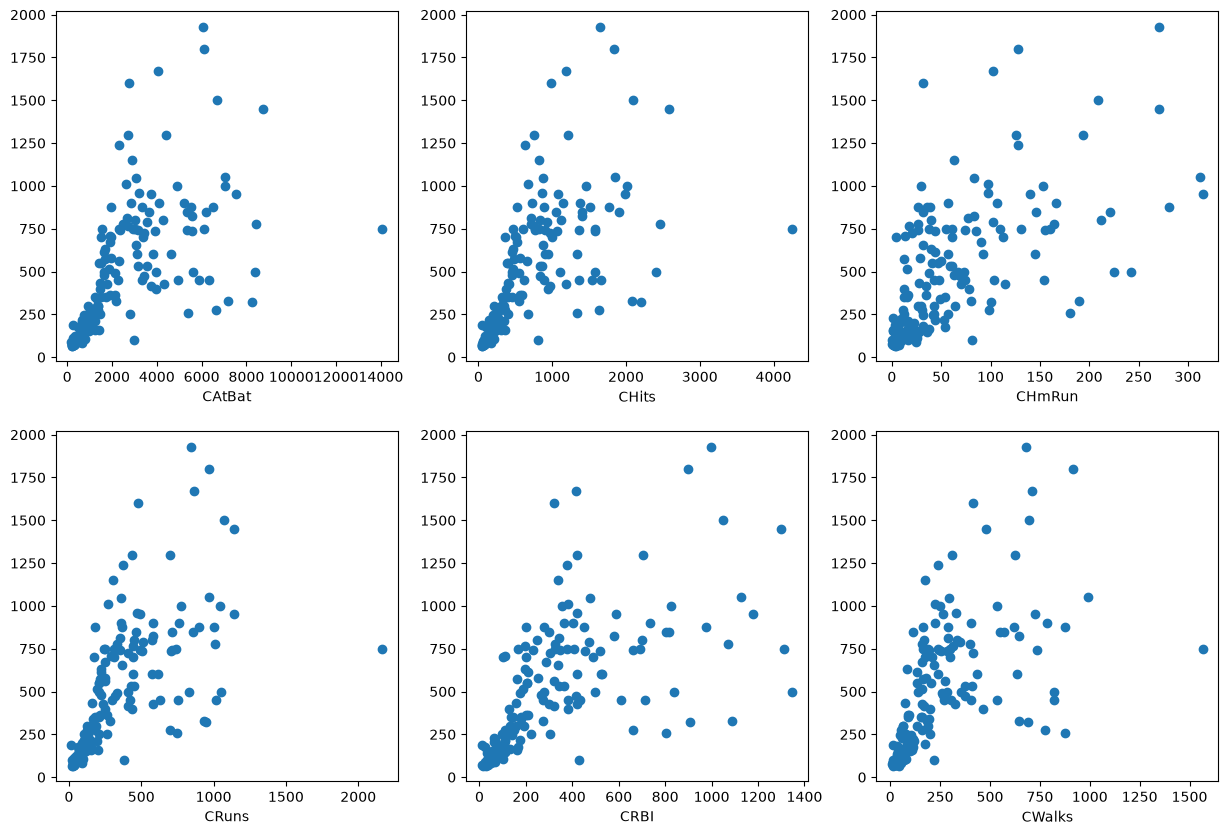

In [12]:
# First create a subset of the columns that we want to plot

subset = Train[['CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']]

# Initialize the plots before drawing them

fig, axes = subplots(nrows=2,
                     ncols=3,
                     figsize=(15, 10))
# Copy the helper function

def range_to_grid(i,Ncol):
    x=[]
    y=[]
    for n in range(Ncol**2):
        x.append(int(np.floor(n/Ncol)))
        y.append(n % Ncol)
        #print(n,x[n],y[n])
    return x[i],y[i]

# Plot the variables

for j in range(len(subset.columns)):
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].plot(subset.iloc[:,j], Train['Salary'], 'o')
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].set_xlabel(subset.columns[j])


### Use the "describe" method to determine the mean, standard deviation, and 5 number summary of all numeric variables in the training subset of _Hitters_.

In [13]:
#fillin
Hitters.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


### It looks like the mean and median of 'AtBat' are nearly equal. This _might_ suggest that this variable is normally distributed. Create a histogram of 'AtBat' to check this hypothesis.

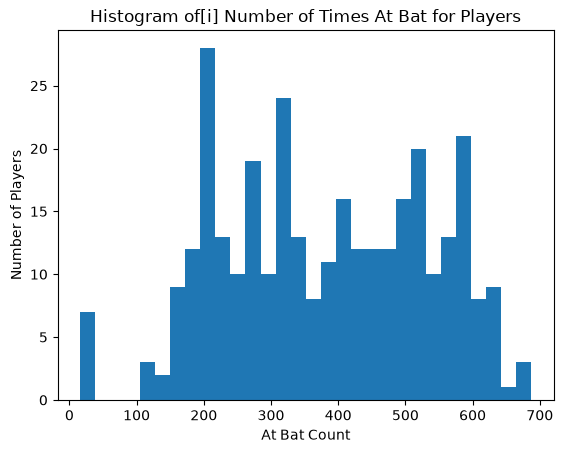

In [ ]:
#fillin

fig, axs = plt.subplots(1, 1)
axs.hist(Hitters['AtBat'], bins=30)
axs.set_xlabel("At Bat Count")
axs.set_ylabel("Number of Players")
axs.set_title("Histogram of Number of Times At Bat for Players")
plt.show()

### Let's standardize the AtBat feature (i.e., normalize by z-scores). We'll create a new column in the training data called 'AtBat_st' to represent this.

In [189]:
#fillin
Train['AtBat_st'] = (Hitters['AtBat']-Hitters['AtBat'].mean())/Hitters['AtBat'].std()
AtBat_st = (Hitters['AtBat']-Hitters['AtBat'].mean())/Hitters['AtBat'].std()#(Hitters['AtBat']-Hitters.describe()['AtBat']['mean'])/Hitters.describe()['AtBat']['std']
Hitters['AtBat_st'] = (Hitters['AtBat']-Hitters['AtBat'].mean())/Hitters['AtBat'].std()

### How many rows have an 'AtBat' value within the first standard deviation?

Hint: the 'len' magic method returns the number of rows of a dataFrame.

In [151]:
#fillin
AtBat_rows_first_std = 0
for i in range(322):
    if Hitters['AtBat_st'][i] >= -1 and Hitters['AtBat_st'][i] <= 1:
        AtBat_rows_first_std += 1
print(AtBat_rows_first_std)

190


### Going back to the results of the 'describe' method, how can you tell that the 'Salary' variable has missing values?

#fillin Type your answer here.
# The "count" row lists the number of instances of a reported salary as less than the number of rows (~322)

### Describe a situation where a variable could have missing values but this would not be reflected in the results of the 'describe' method.

#fillin Type your answer here.
# Perhaps if the variable had a missing value, but in the table there was some placeholder to indicate that it had a missing value, like ("NULL") rather than being empty.

### On the training data, create separate boxplots of the 'AtBat' variable for when 'Salary' is populated or missing.

C:\Users\jwlow\AppData\Local\Temp\ipykernel_18632\1002970239.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(Hitters[Hitters['Salary'].isnull()]['AtBat'], vert=False)
C:\Users\jwlow\AppData\Local\Temp\ipykernel_18632\1002970239.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(Hitters[~Hitters['Salary'].isnull()]['AtBat'], vert=False)


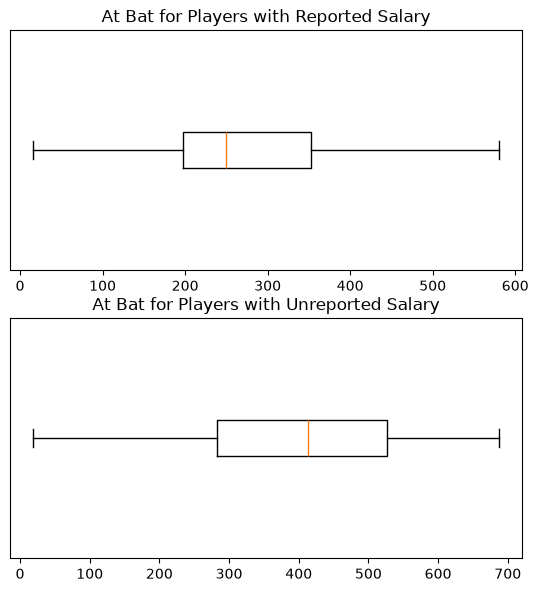

In [167]:
#fillin
#https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_adjust.html
#https://stackoverflow.com/questions/18500011/horizontal-box-plots-in-matplotlib-pandas
#https://matplotlib.org/stable/users/explain/text/text_intro.html
#https://stackoverflow.com/questions/42818361/how-to-make-two-plots-side-by-side
# Among others
plot = plt.subplot(2, 1, 1)
plot.set_title("At Bat for Players with Reported Salary")
plt.boxplot(Hitters[Hitters['Salary'].isnull()]['AtBat'], vert=False)
plt.yticks(ticks=[])
plot2 = plt.subplot(2,1,2)
plot2.set_title("At Bat for Players with Unreported Salary")
plt.boxplot(Hitters[~Hitters['Salary'].isnull()]['AtBat'], vert=False)
plt.subplots_adjust(bottom=0.1,top=1.2,right=0.9,left=0.1)
plt.yticks(ticks=[])
plt.show()

### Create a correlation matrix for all numeric features in the training set

In [93]:
#fillin
#https://stackoverflow.com/questions/29432629/plot-correlation-matrix-using-pandas
#https://stackoverflow.com/questions/25039626/how-do-i-find-numeric-columns-in-pandas
Hitters.select_dtypes(include='number').corr()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,AtBat_st
AtBat,1.000000,0.967939,0.592198,0.913060,0.820539,0.669845,0.047372,0.235526,0.252717,0.236659,0.266534,0.244053,0.166123,0.317550,0.353824,0.352117,0.394771,1.000000
Hits,0.967939,1.000000,0.562158,0.922187,0.811073,0.641211,0.044767,0.227565,0.255815,0.202712,0.261787,0.232005,0.151818,0.310673,0.320455,0.310038,0.438675,0.967939
HmRun,0.592198,0.562158,1.000000,0.650988,0.855122,0.481014,0.116318,0.221882,0.220627,0.493227,0.262361,0.351979,0.233154,0.282923,-0.106329,0.039318,0.343028,0.592198
Runs,0.913060,0.922187,0.650988,1.000000,0.798206,0.732213,0.004541,0.186497,0.204830,0.227913,0.250556,0.205976,0.182168,0.279347,0.220567,0.240475,0.419859,0.913060
RBI,0.820539,0.811073,0.855122,0.798206,1.000000,0.615997,0.146168,0.294688,0.308201,0.441771,0.323285,0.393184,0.250914,0.343186,0.106591,0.193370,0.449457,0.820539
Walks,0.669845,0.641211,0.481014,0.732213,0.615997,1.000000,0.136475,0.277175,0.280671,0.332473,0.338478,0.308631,0.424507,0.299515,0.149656,0.129382,0.443867,0.669845
Years,0.047372,0.044767,0.116318,0.004541,0.146168,0.136475,1.000000,0.920289,0.903631,0.726872,0.882877,0.868812,0.838533,-0.004684,-0.080638,-0.162140,0.400657,0.047372
CAtBat,0.235526,0.227565,0.221882,0.186497,0.294688,0.277175,0.920289,1.000000,0.995063,0.798836,0.983345,0.949219,0.906501,0.062283,0.002038,-0.066922,0.526135,0.235526
CHits,0.252717,0.255815,0.220627,0.204830,0.308201,0.280671,0.903631,0.995063,1.000000,0.783306,0.984609,0.945141,0.890954,0.076547,-0.002523,-0.062756,0.548910,0.252717
CHmRun,0.236659,0.202712,0.493227,0.227913,0.441771,0.332473,0.726872,0.798836,0.783306,1.000000,0.820243,0.929484,0.799983,0.112724,-0.158511,-0.138115,0.524931,0.236659


### Propose two different ways of imputing the missing values of Salary while taking advantage of the information given in the boxplots or the correlation matrix.

#fillin Type your answer here.
# According to the correlation matrix, the CRBI is most correlated with salary. So, one could perhaps construct a regression model with CRBI. Or, One could sample a few high correlation values in the table and build a better regression model developed over a few variables (multiple regression model?). One could also take the Q1 to Q3 values for the no-salary players, find the salaries of those with salaries with at bats in those ranges, take the median, and then impute that into the salaries. But, the regression model seems better.

### For our last exercise, we'll explore Hits and Walks relative to AtBat totals. 
- Use the sum function to calculuate the totals of each of these three variables for the 1986 season (on the training set). 
- Create a pie chart which shows total hits, total walks, and remaining total (neither) as percents of the At Bats total (on the training set). 

In [94]:
TotHits = Hitters['Hits'].sum()#fillin
TotWalks = Hitters['Walks'].sum()#fillin
TotAtBat = Hitters['AtBat'].sum()#fillin

Labels = ['Hits', 'Walks', 'Neither']
Totals = [TotHits, TotWalks, TotAtBat-TotHits-TotWalks]

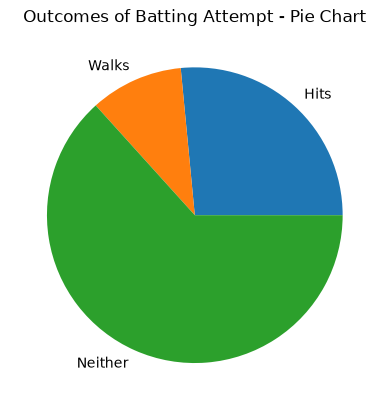

In [154]:
# pie chart
#https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_label.html
fig, ax = plt.subplots()
ax.pie(Totals, labels=Labels)
ax.set_title("Outcomes of Batting Attempt - Pie Chart")
plt.show()

### The previous two cells gave us totals across all players. For each player in the training set, calculate the Hits as a percent of AtBat and store it in a new variable called 'AVG'

In [ ]:
#fillin
Train['AVG'] = Train['Hits']/Train['AtBat']

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague,AVG_bin,AVG


### Using 0.25 and 0.31 as the split points, create a new variable with three bins: high, medium, and low. 

In [132]:
Train['AVG_bin'] = 'medium'
Train.loc[Train['AVG']<.25, 'AVG_bin'] = 'low'
Train.loc[Train['AVG']>.31, 'AVG_bin'] = 'high'

### Create a bar chart that displays the number of players in each of the low, medium, and high categories (for the training data).

In [133]:
Train['AVG_bin'].value_counts()

AVG_bin
medium    114
low        65
high       14
Name: count, dtype: int64

Notice that the order of the bars will be medium, low, high. That's counterintuitive. We can reorder these quickly. 

In [134]:
indexMap = ['low', 'medium', 'high']
reordered_list = [Train['AVG_bin'].value_counts()[i] for i in indexMap]

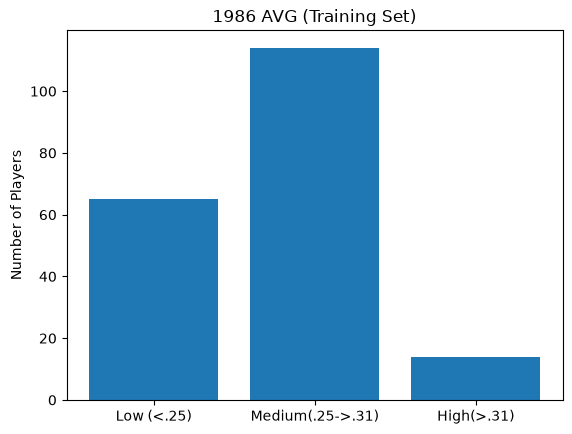

In [165]:
plt.bar(['Low', 'Medium', 'High'], reordered_list)#fillin

plt.title("1986 AVG (Training Set)")
plt.ylabel("Number of Players")

plt.xticks(ticks=[0,1,2],labels=["Low (<.25)", "Medium(.25->.31)", "High(>.31)"])#fillin. Sorry, wasn't sure exactly what was being asked here, oops.

plt.show()

### Did we use the depth method or width method for creating these bins? Explain.

#fillin Type your answer here.
# We didn't use depth here, because the bins aren't filled by frequency. There is a different number of players in each bin. Furthermore, if you look at the distribution of the data, 0.06 is roughly the size of each resulting bin. No player has an AVG of over .37, and no player has an AVG of under .19, which are both about 0.06 above and below the bounds given by the middle bin, which also has a width of about 0.06, from 0.25 to 0.31. It seems best to say we used the width method here.